In [15]:
### Deconvolution
from csbdeep.models import CARE
from csbdeep.utils import normalize

### Segmentation
from cellpose_omni import models
from omnipose.utils import normalize99

### Measurement
from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ParamSampler
from MEDUSSA.utils import CellColorer

### Plotting
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

### Visualization
from skimage import io
from skimage.color import label2rgb

### Other
import numpy as np
import pandas as pd
from skimage.measure import regionprops_table

### Read the image 
fm_image = io.imread('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/BsubtilismVenus_026_FM.tif')


In [2]:
### Load the deconvolution model

model_dir = '/Users/reyesmatte/models/CARE/'
model_2D = CARE(config=None, name='CARE_FM2FM', basedir=model_dir)

### Predict deconvolved image
fm_deconvolution = model_2D.predict(normalize(fm_image),axes='YX',n_tiles=(4,4))

Loading network weights from 'weights_best.h5'.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:02<00:00,  5.53it/s]


In [3]:
### Load the segmentation model and specify model parameters
params = {'rescale': None, # upscale or downscale your images, None = no rescaling 

          'mask_threshold': 0, # erode or dilate masks with higher or lower values 

          'flow_threshold': 0.4, # default is .4, but only needed if there are spurious masks to clean up; slows down output

          'transparency': True, # transparency in flow output

          'omni': True, # we can turn off Omnipose mask reconstruction, not advised 

          'cluster': True, # use DBSCAN clustering

          'resample': True, # whether or not to run dynamics on rescaled grid or original grid 

          # 'verbose': False, # turn on if you want to see more output 

          'tile': False, # average the outputs from flipped (augmented) images; slower, usually not needed 

          'niter': None, # None lets Omnipose calculate # of Euler iterations (usually <20) but you can tune it for over/under segmentation 

          'augment': False, # Can optionally rotate the image and average outputs, usually not needed 

          'affinity_seg': False, # new feature, stay tuned...

         }

model_path = '/Users/reyesmatte/models/Omnipose/FMSeg'
model = models.CellposeModel(pretrained_model=model_path, nclasses=3, nchan=1, gpu=False, diam_mean=0)

masks, flows, styles = model.eval(normalize99(fm_deconvolution),**params)

2025-10-17 16:21:17,379 [INFO] >>>> using CPU
2025-10-17 16:21:17,379 [INFO] WARNING: MKL version on torch not working/installed - CPU version will be slightly slower.
2025-10-17 16:21:17,380 [INFO] see https://pytorch.org/docs/stable/backends.html?highlight=mkl


In [4]:
### Measure

measurements = SizeDataFrame([masks],from_files=False)
measurements.insert(0,'Experiment','Test')
metrics = measurements.columns[2:]

### Transform
df_posteriors = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Figures/FigureS4/posterior_segmentation_measurements.csv')

transformed_measurements = ParamSampler(data_df=measurements,posterior_df=df_posteriors,columns=['Experiment'],metrics=metrics)
labels = regionprops_table(label_image=masks,properties=['label'])['label']
transformed_measurements.insert(1,'Label',labels)

masks_by_width = CellColorer(masks,labels,np.array(transformed_measurements['Width_mu']))
masks_by_length = CellColorer(masks,labels,np.array(transformed_measurements['Length_mu']))

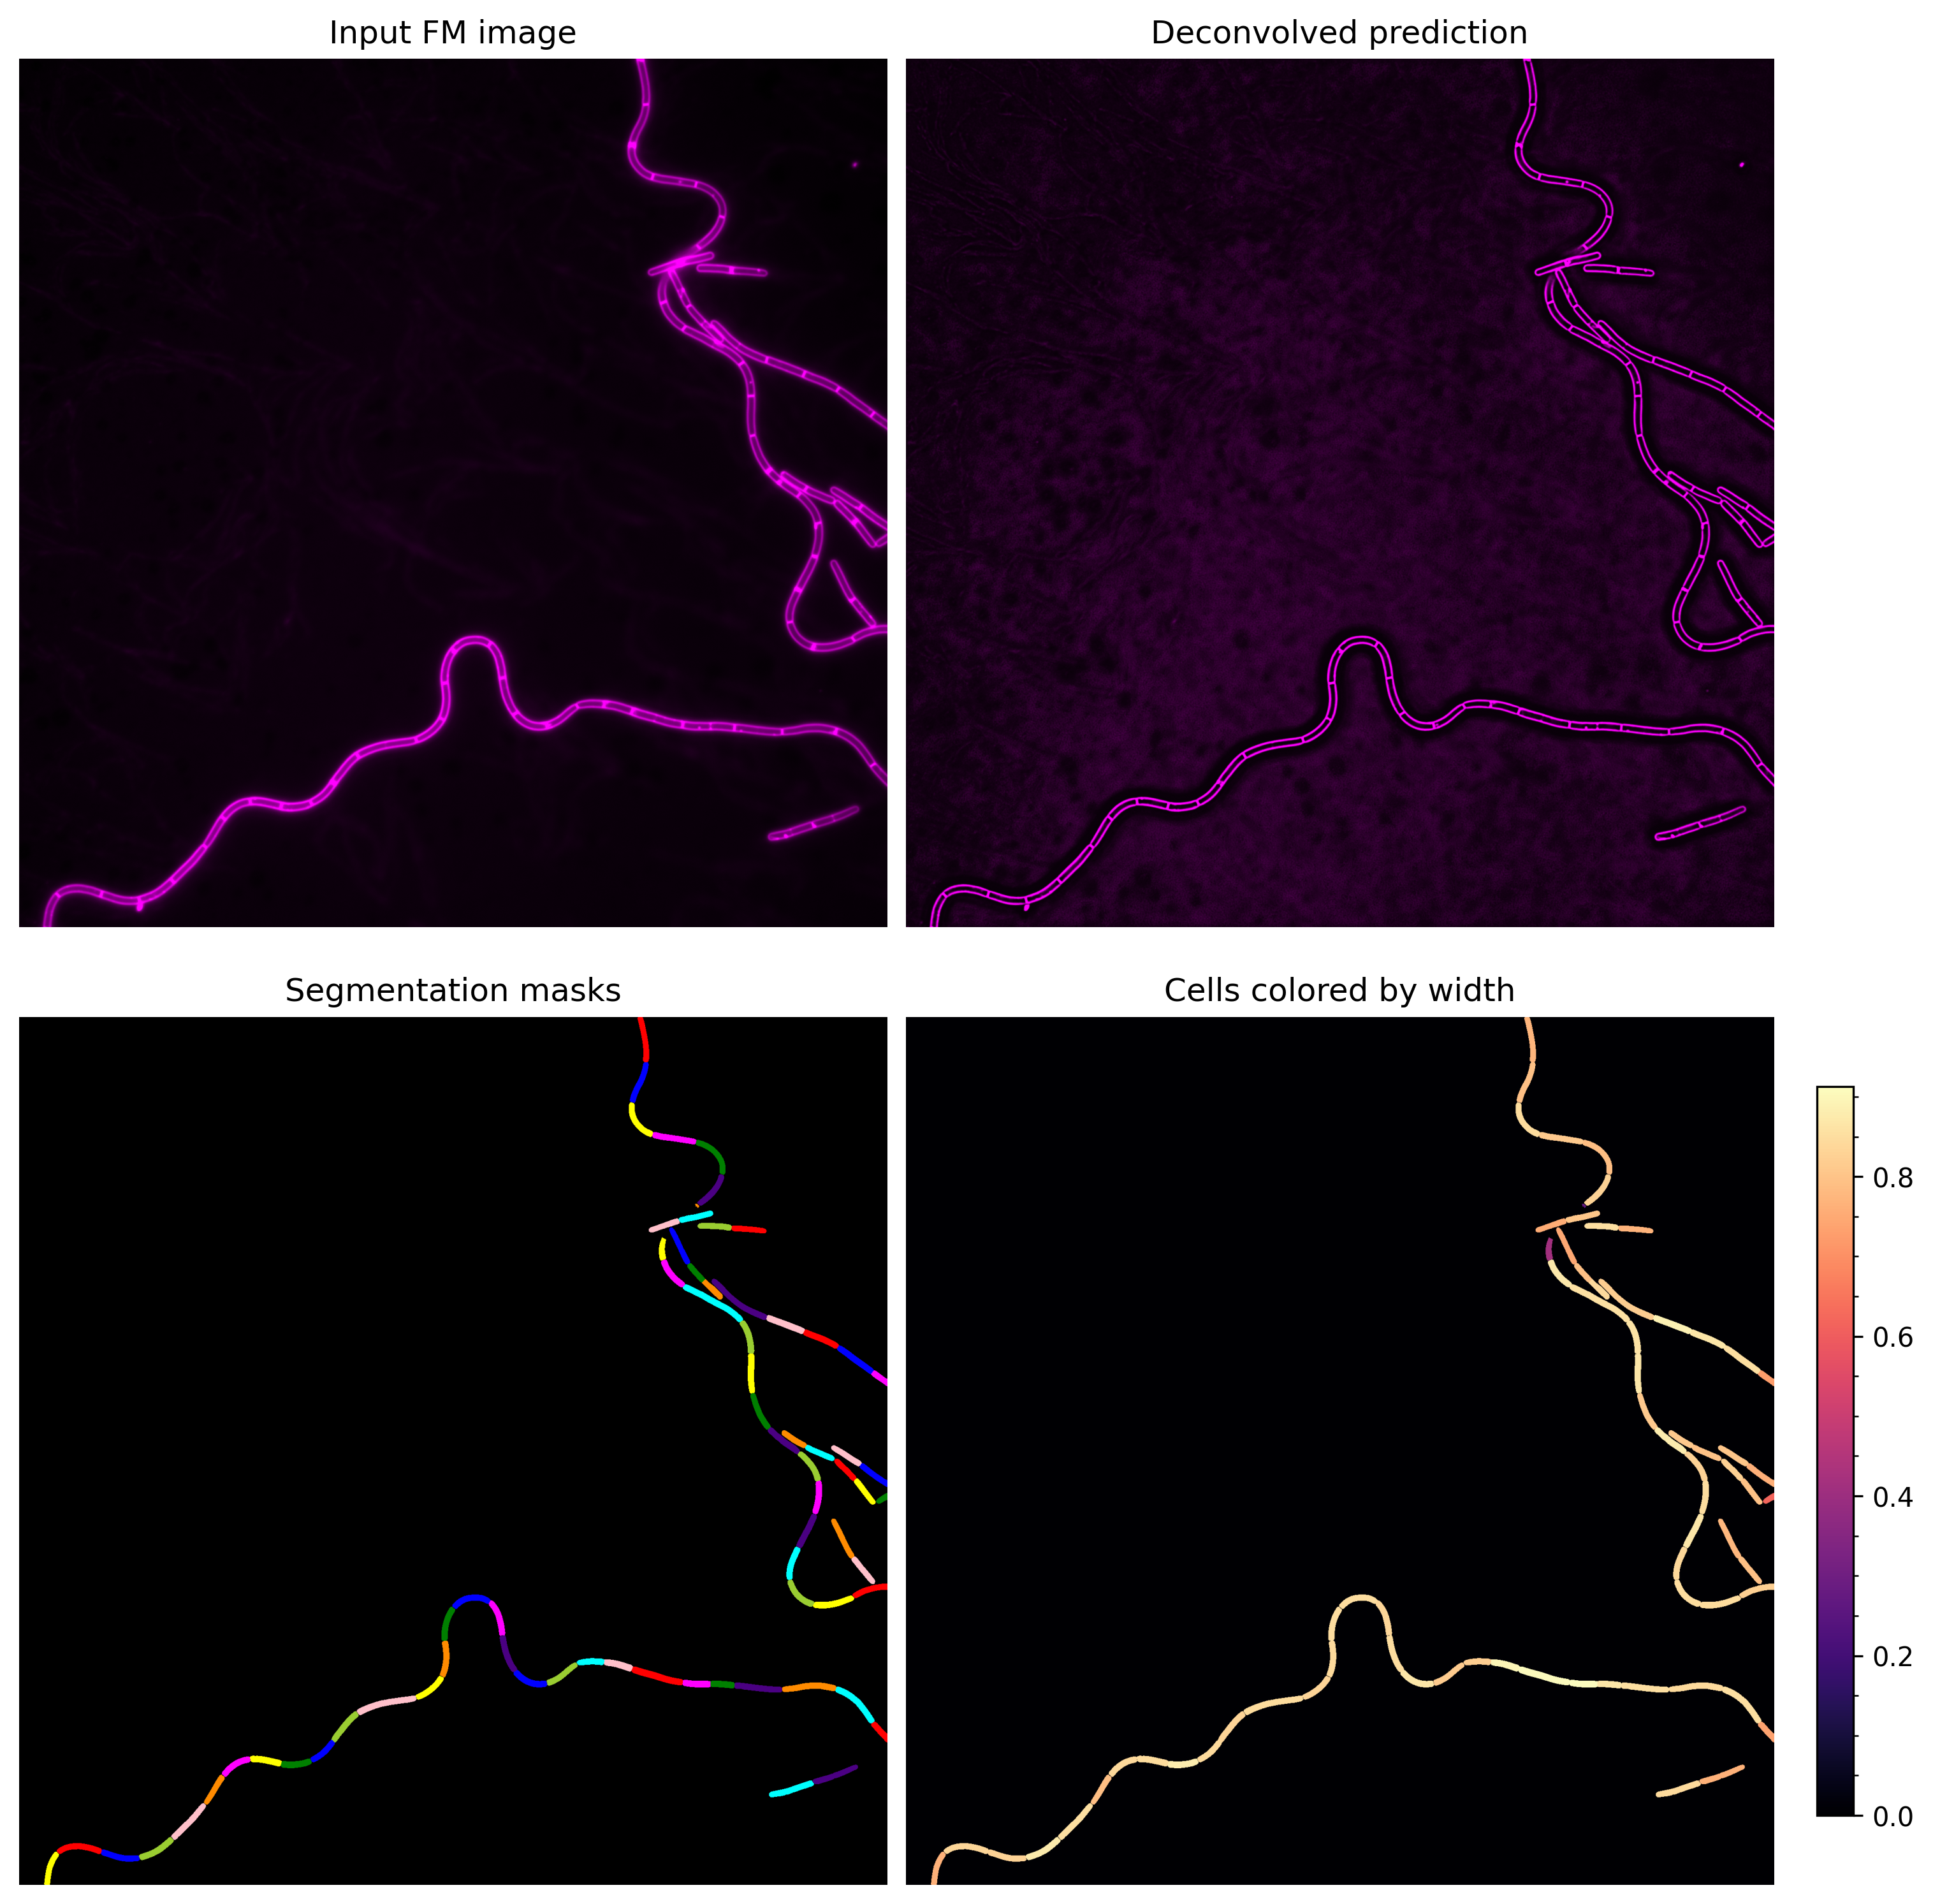

In [5]:
## Assemble!
cmap = LinearSegmentedColormap.from_list('magenta',[(0, 0, 0), (1, 0, 1)],N=256)
fig,ax = plt.subplots(dpi=300,figsize=(10,10),ncols=2,nrows=2,layout='constrained')

ax[0,0].imshow(normalize(fm_image),cmap=cmap,vmax=1)
ax[0,0].axis('off')
ax[0,0].set_title('Input FM image')

ax[0,1].imshow(normalize(fm_deconvolution),cmap=cmap,vmax=0.7)
ax[0,1].axis('off')
ax[0,1].set_title('Deconvolved prediction')

ax[1,0].imshow(label2rgb(masks))
ax[1,0].axis('off')
ax[1,0].set_title('Segmentation masks')

pos = ax[1,1].imshow(masks_by_width,cmap='magma')#,vmin=0.5,vmax=1)
ax[1,1].set_title('Cells colored by width')
ax[1,1].axis('off')
cbar = fig.colorbar(pos,shrink=0.8)
cbar.minorticks_on()
